# Olist Customer Retention Analysis - Insight

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

## 1.1 Load Environment & Database Connection

In [2]:
load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_NAME_ANALYTICS = os.getenv("DB_NAME_ANALYTICS")

In [3]:
# koneksi ke MySQL
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

## 2. BQ1 - Perbandingan Sekali Order vs Repeat Order

In [4]:
query1 = """
WITH freq_cust AS
    (
    SELECT sc.customer_unique_id AS customer_unique_id,
            COUNT(so.order_id) AS count_order,
            CASE 
                WHEN COUNT(so.order_id) = 1 THEN 'sekali order'
                ELSE 'repeat order'
            END AS kategori
    FROM stg_orders AS so
    JOIN stg_customers AS sc 
        ON so.customer_id = sc.customer_id
    WHERE so.order_status = 'delivered'
    GROUP BY sc.customer_unique_id
    )

SELECT kategori, 
        COUNT(customer_unique_id) AS total_order,
        ROUND((COUNT(customer_unique_id) / (SELECT COUNT(customer_unique_id) FROM freq_cust)), 2) * 100 AS persentase
FROM freq_cust
GROUP BY kategori;
"""

df_bq1 = pd.read_sql(query1, engine)

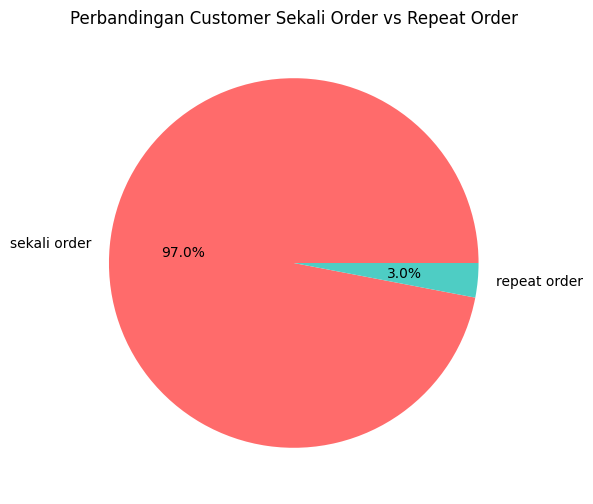

In [5]:
# visualisasi BQ1
plt.figure(figsize=(6, 6))
plt.pie(
    df_bq1['total_order'],
    labels=df_bq1['kategori'],
    autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4']
)
plt.title('Perbandingan Customer Sekali Order vs Repeat Order')
plt.show()

**Insight:**
**97% pelanggan** hanya melakukan 1 kali pembelian. Tingkat retensi sangat rendah yang di mana mayoritas pelanggan tidak kembali lagi setelah pembelian pertama.

## 3. BQ2 - Kategori Produk Repeat Order

In [6]:
query2 = """
SELECT spt.product_category_name_english AS kategori_produk,
       COUNT(soi.order_id) AS jumlah_order
FROM stg_order_items AS soi
        JOIN stg_orders AS so ON soi.order_id = so.order_id
        JOIN stg_customers AS sc ON so.customer_id = sc.customer_id
        JOIN stg_customers AS sc2 ON sc.customer_unique_id = sc2.customer_unique_id
        JOIN stg_orders AS so2 ON sc2.customer_id = so2.customer_id
        JOIN stg_products AS sp ON soi.product_id = sp.product_id
        JOIN stg_product_translation AS spt ON sp.product_category_name = spt.product_category_name
WHERE so.order_status = 'delivered'
GROUP BY spt.product_category_name_english
HAVING COUNT(DISTINCT sc.customer_unique_id) > 1
ORDER BY jumlah_order DESC
LIMIT 10;
"""

df_bq2 = pd.read_sql(query2, engine)

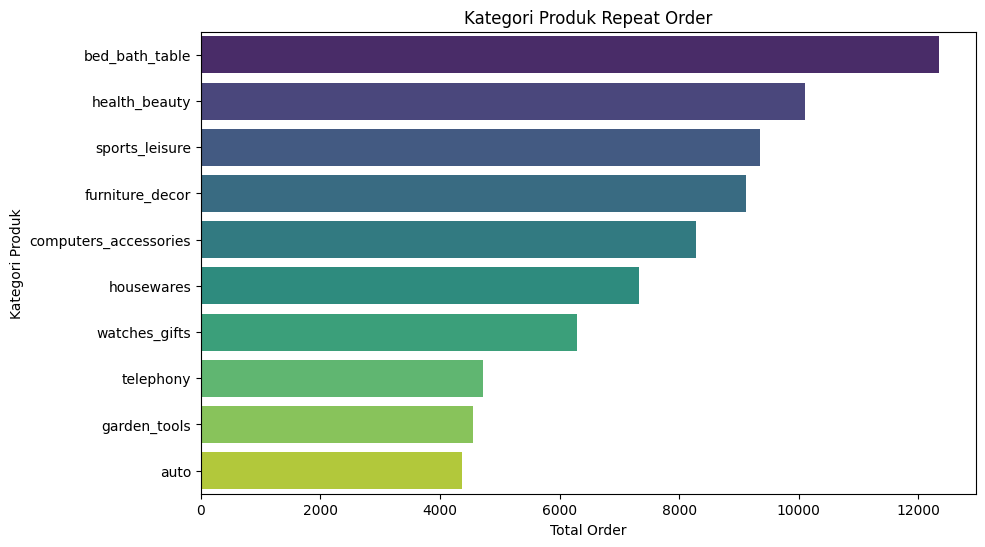

In [7]:
# visualisasi BQ2
plt.figure(figsize=(10, 6))
sns.barplot(data=df_bq2, x='jumlah_order', y='kategori_produk', hue='kategori_produk', palette='viridis')
plt.title('Kategori Produk Repeat Order')
plt.xlabel('Total Order')
plt.ylabel('Kategori Produk')
plt.show()

**Insight:**
`bed_bath_table` dan `health_beauty` merupakan kategori produk rumah tangga yang paling sering di repeat order. 

## 4. BQ3 - Distribusi Review Score Repeat Order

In [8]:
query3_avg = """
WITH repeat_cust AS
    (
    SELECT 
        sc.customer_unique_id AS customer_unique_id,
        COUNT(so.order_id) AS total_order,
        CASE
            WHEN COUNT(so.order_id) = 1 THEN 'sekali beli'
            ELSE 'repeat order'
        END AS kategori,
        AVG(sor.review_score) AS review_score
    FROM stg_customers AS sc
        JOIN stg_orders AS so ON sc.customer_id = so.customer_id
        JOIN stg_order_reviews AS sor ON so.order_id = sor.order_id
    WHERE so.order_status = 'delivered'
    GROUP BY sc.customer_unique_id
    )

SELECT kategori,
    ROUND(AVG(review_score), 2) AS avg_rating
FROM repeat_cust
WHERE kategori = 'repeat order'
GROUP BY kategori;
"""
df_bq3_avg = pd.read_sql( query3_avg, engine)

In [9]:
query3_dist = """
WITH repeat_cust AS
    (
    SELECT 
        sc.customer_unique_id AS customer_unique_id,
        COUNT(so.order_id) AS total_order,
        CASE
            WHEN COUNT(so.order_id) = 1 THEN 'sekali beli'
            ELSE 'repeat order'
        END AS kategori,
        AVG(sor.review_score) AS review_score
    FROM stg_customers AS sc
        JOIN stg_orders AS so ON sc.customer_id = so.customer_id
        JOIN stg_order_reviews AS sor ON so.order_id = sor.order_id
    WHERE so.order_status = 'delivered'
    GROUP BY sc.customer_unique_id
    )

SELECT ROUND(review_score) AS review_score,
    COUNT(customer_unique_id) AS jumlah_customer
FROM repeat_cust
WHERE kategori = 'repeat order'
GROUP BY ROUND(review_score)
ORDER BY review_score;
"""
df_bq3_dist = pd.read_sql(query3_dist, engine)

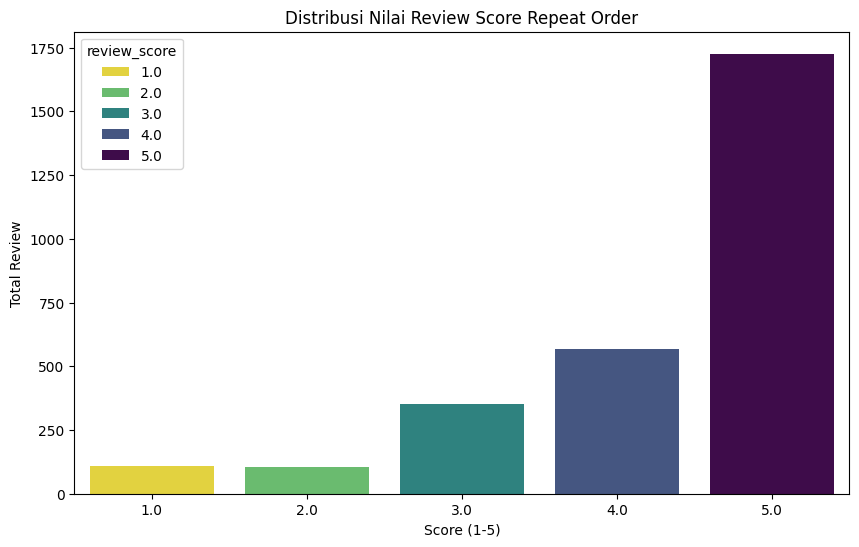

In [10]:
# visualisasi BQ3
plt.figure(figsize=(10, 6))
sns.barplot(data=df_bq3_dist, x='review_score', y='jumlah_customer', hue='review_score', palette='viridis_r')
plt.title("Distribusi Nilai Review Score Repeat Order")
plt.xlabel('Score (1-5)')
plt.ylabel('Total Review')
plt.show()

**Insight:**
Rata-rata nilai review score pelanggan repeat order adalah **4.2/5** yang mayoritas pelanggan memberikan nilai (5) sebanyak **1.726 pelanggan**, namun masih ada 211 pelanggan yang memberi nilai 1 dan 2 tetapi tetap kembali membeli.

## 5. BQ4 - Metode Pembayaran Repeat Order

In [11]:
query4 = """
WITH repeat_order AS
    (
        SELECT 
            sc.customer_unique_id AS customer_unique_id,
            COUNT(so.order_id) AS total_order,
            CASE
                WHEN COUNT(so.order_id) = 1 THEN 'sekali beli'
                ELSE 'repeat order'
            END AS kategori,
            sop.payment_method AS payment_method
        FROM stg_customers AS sc 
        JOIN stg_orders AS so ON sc.customer_id = so.customer_id
        JOIN stg_order_items AS soi ON so.order_id = soi.order_id
        JOIN stg_order_payments sop ON soi.order_id = sop.order_id
        WHERE so.order_status = 'delivered'
        GROUP BY sc.customer_unique_id, sop.payment_method
    )

    SELECT 
        payment_method,
        COUNT(customer_unique_id) AS jumlah_customer
    FROM repeat_order
    WHERE kategori = 'repeat order'
    GROUP BY payment_method
    ORDER BY jumlah_customer DESC;
"""
df_bq4 = pd.read_sql(query4, engine)

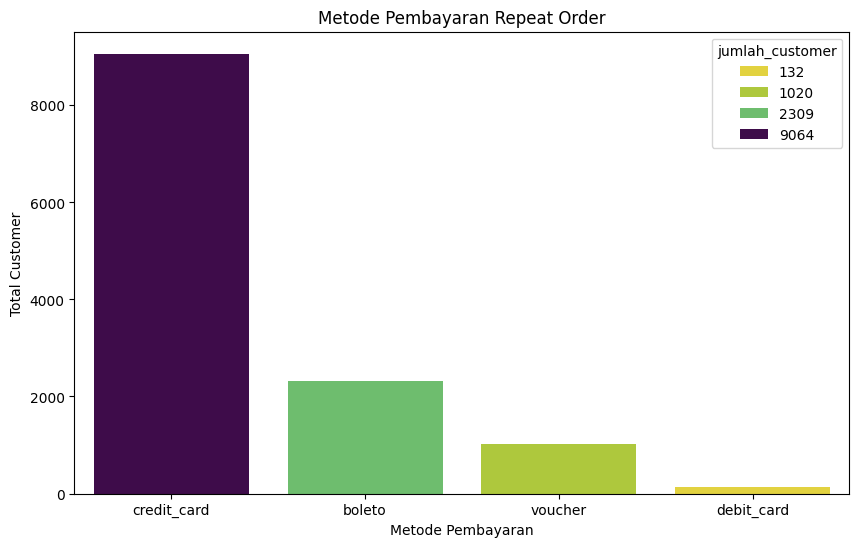

In [12]:
# visualisasi BQ4
plt.figure(figsize=(10, 6))
sns.barplot(data=df_bq4, x='payment_method', y='jumlah_customer', hue='jumlah_customer', palette='viridis_r')
plt.title('Metode Pembayaran Repeat Order')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Total Customer')
plt.show()

**Insight:**
`credit_card` merupakan metode pembayaran yang paling mendominasi pelanggan repeat order sebanyak **9.064 pelanggan** dan sangat jarang ada pelanggan yang menggunakan `debit_card`.

## 6. BQ5 - Ketepatan Pengiriman Repeat Order

In [13]:
query5 = """
WITH repeat_cust AS
    (
        SELECT 
            sc.customer_unique_id AS customer_unique_id,
            COUNT(so.order_id) AS total_order,
            CASE
                WHEN COUNT(so.order_id) = 1 THEN 'sekali beli'
                ELSE 'repeat order'
            END AS kategori
        FROM stg_customers AS sc
        JOIN stg_orders AS so ON sc.customer_id = so.customer_id
        WHERE so.order_status = 'delivered'
        GROUP BY sc.customer_unique_id
    ),
    cust_date AS
    (
        SELECT 
            sc.customer_unique_id AS customer_unique_id,
            MAX(so.order_delivered_customer_date) AS delivered_date,
            MAX(so.order_estimated_delivery_date) AS estimated_date
        FROM stg_customers AS sc
        JOIN stg_orders AS so ON sc.customer_id = so.customer_id
        WHERE so.order_status = 'delivered'
        GROUP BY sc.customer_unique_id
    )

SELECT kategori,
        CASE 
            WHEN DATEDIFF(delivered_date, estimated_date) > 0 THEN 'telat'
            ELSE 'tepat waktu' 
        END AS delivery_diff,
        COUNT(rc.customer_unique_id) AS jumlah_customer
FROM repeat_cust AS rc
    JOIN cust_date AS cd ON rc.customer_unique_id = cd.customer_unique_id
WHERE kategori = 'repeat order'
GROUP BY kategori, 
        CASE 
            WHEN DATEDIFF(delivered_date, estimated_date) > 0 THEN 'telat'
            ELSE 'tepat waktu' 
        END;
"""
df_bq5 = pd.read_sql(query5, engine)

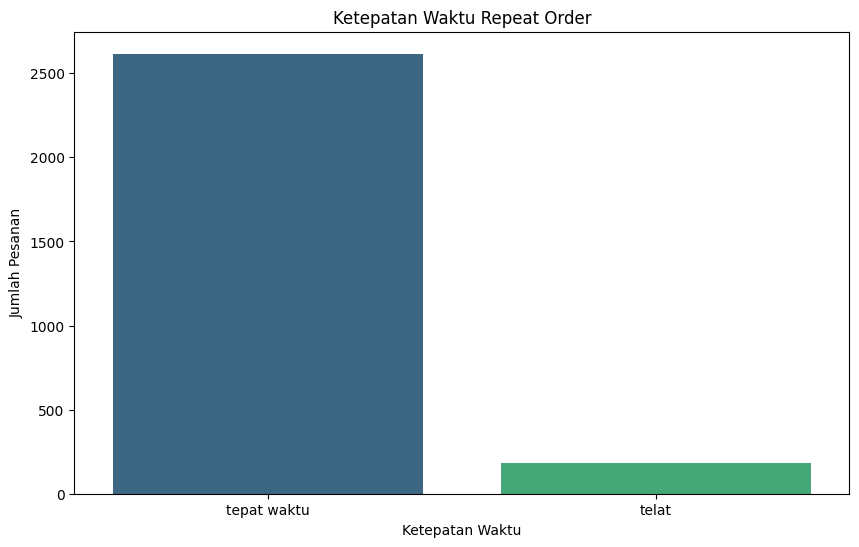

In [14]:
# visualisasi BQ5
plt.figure(figsize=(10, 6))
sns.barplot(data=df_bq5, x='delivery_diff', y='jumlah_customer', hue='delivery_diff',palette='viridis' )
plt.title('Ketepatan Waktu Repeat Order')
plt.xlabel('Ketepatan Waktu')
plt.ylabel('Jumlah Pesanan')
plt.show()

**Insight:**    
Pengiriman pesanan repeat order lebih banyak yang tepat waktu sebanyak **2.616 pelanggan**, sedangkan yang **telat** sebanyak **185 pelanggan**. Ini menandakan adanya pengaruh ketepatan waktu terhadap repeat order.